# Experimental Analysis and Visualisation

**Project:** Graph-Constrained Vector Retrieval for Mitigating Structural Failure Modes in Naive RAG  
**Student:** Bharath Parimanan | MSc Data Science | 7PAM2002  

This notebook generates all plots and figures used in the project presentation and dissertation.

| Section | Content |
|---|---|
| 1 | Imports and config |
| 2 | Load all result files |
| 3 | QASPER EDA — dataset distribution |
| 4 | Chunk analysis — V0 vs V1 token length |
| 5 | Results comparison — V0 vs V1 vs V2 |
| 6 | Per-query breakdown heatmap |
| 7 | Provenance Coverage — V2 only |
| 8 | Graph statistics |
| 9 | Failure mode analysis |

All figures saved to `figures/` directory.

## Section 1 — Imports and Config

In [4]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Figure output directory
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Colour palette — dark navy theme consistent with presentation
NAVY      = '#1F3864'
BLUE      = '#2E5FA3'
TEAL      = '#028090'
GOLD      = '#D4A843'
LIGHT     = '#EEF2F7'
WHITE     = '#FFFFFF'
GREY      = '#666666'
RED       = '#C0392B'
GREEN     = '#27AE60'

VARIANT_COLOURS = {
    'V0': RED,
    'V1': GOLD,
    'V2': GREEN,
}

# ── Global matplotlib style
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          12,
    'axes.titlesize':     14,
    'axes.labelsize':     12,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.facecolor':     WHITE,
    'figure.facecolor':   WHITE,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         150,
})

print('Imports and config ready.')
print(f'Figures will be saved to: {FIGURES_DIR}/')

Imports and config ready.
Figures will be saved to: figures/


## Section 2 — Load All Result Files

In [6]:
DATA_DIR = 'data'

# Load results
with open(os.path.join(DATA_DIR, 'v0_results.json')) as f:
    v0_data = json.load(f)

with open(os.path.join(DATA_DIR, 'v1_results.json')) as f:
    v1_data = json.load(f)

with open(os.path.join(DATA_DIR, 'v2_results.json')) as f:
    v2_data = json.load(f)

# Load chunks
with open(os.path.join(DATA_DIR, 'v0_chunks.json')) as f:
    v0_chunks = json.load(f)

with open(os.path.join(DATA_DIR, 'v1_chunks.json')) as f:
    v1_chunks = json.load(f)

# Load queries
with open(os.path.join(DATA_DIR, 'queries.json')) as f:
    queries = json.load(f)

# Extract per-query results
v0_results = [r for r in v0_data['results'] if r.get('status') == 'success']
v1_results = [r for r in v1_data['results'] if r.get('status') == 'success']
v2_results = [r for r in v2_data['results'] if r.get('status') == 'success']

print(f'V0 results: {len(v0_results)} queries')
print(f'V1 results: {len(v1_results)} queries')
print(f'V2 results: {len(v2_results)} queries')
print(f'V0 chunks:  {len(v0_chunks):,}')
print(f'V1 chunks:  {len(v1_chunks):,}')
print(f'Queries:    {len(queries)}')

V0 results: 10 queries
V1 results: 10 queries
V2 results: 10 queries
V0 chunks:  22,165
V1 chunks:  46,882
Queries:    10


## Section 3 — QASPER EDA

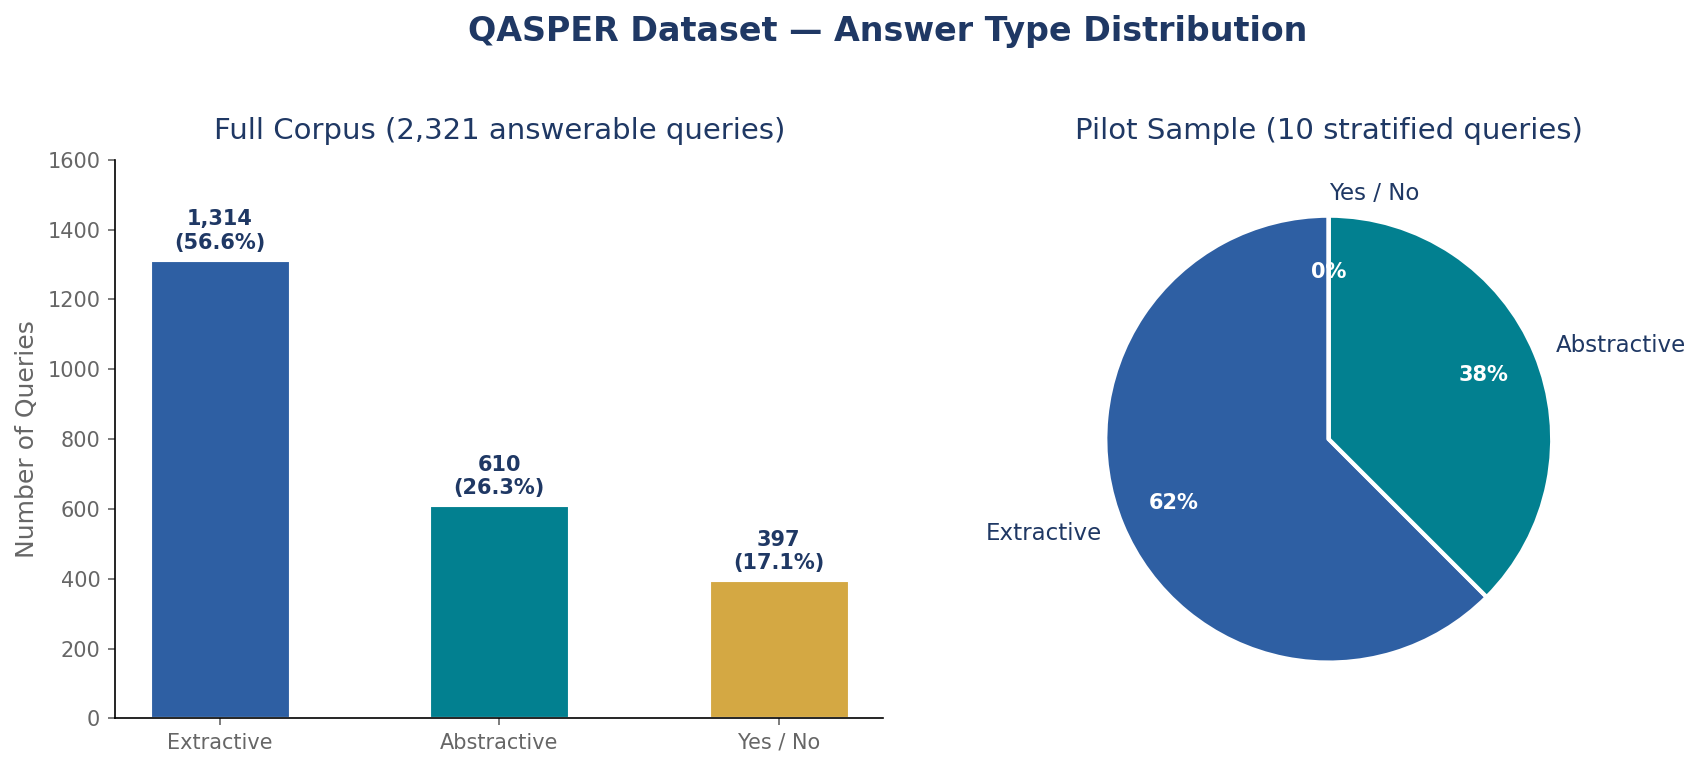

Saved → figures/fig1_qasper_distribution.png


In [8]:
# ── Figure 1: QASPER Answer Type Distribution
# Full corpus distribution (from extraction results)
corpus_counts = {'Extractive': 1314, 'Abstractive': 610, 'Yes / No': 397}
sample_counts = {}
for q in queries:
    t = q['answer_type'].replace('_', ' ').title()
    sample_counts[t] = sample_counts.get(t, 0) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('QASPER Dataset — Answer Type Distribution', fontsize=16, fontweight='bold', color=NAVY, y=1.02)

# Corpus distribution
labels  = list(corpus_counts.keys())
values  = list(corpus_counts.values())
colours = [BLUE, TEAL, GOLD]
total   = sum(values)

bars = axes[0].bar(labels, values, color=colours, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({100*val/total:.1f}%)', ha='center', va='bottom',
                 fontsize=10, color=NAVY, fontweight='bold')
axes[0].set_title('Full Corpus (2,321 answerable queries)', color=NAVY, pad=10)
axes[0].set_ylabel('Number of Queries', color=GREY)
axes[0].set_ylim(0, 1600)
axes[0].tick_params(colors=GREY)

# Pilot sample distribution
s_labels  = ['Extractive', 'Abstractive', 'Yes / No']
s_values  = [sample_counts.get(l, 0) for l in s_labels]
wedges, texts, autotexts = axes[1].pie(
    s_values,
    labels=s_labels,
    colors=colours,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for text in texts:
    text.set_color(NAVY)
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color(WHITE)
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
axes[1].set_title('Pilot Sample (10 stratified queries)', color=NAVY, pad=10)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig1_qasper_distribution.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Section 4 — Chunk Analysis: V0 vs V1

In [10]:
# ── Figure 2: Chunk Statistics Comparison
from sentence_transformers import SentenceTransformer
tokenizer = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2').tokenizer

print('Computing token lengths for sample chunks...')
sample_size = 2000

v0_sample = v0_chunks[:sample_size]
v1_sample = v1_chunks[:sample_size]

v0_lengths = [len(tokenizer.encode(c['chunk_text'], add_special_tokens=False)) for c in v0_sample]
v1_lengths = [len(tokenizer.encode(c['chunk_text'], add_special_tokens=False)) for c in v1_sample]

print(f'V0 — min:{min(v0_lengths)} max:{max(v0_lengths)} mean:{sum(v0_lengths)/len(v0_lengths):.0f}')
print(f'V1 — min:{min(v1_lengths)} max:{max(v1_lengths)} mean:{sum(v1_lengths)/len(v1_lengths):.0f}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (258 > 256). Running this sequence through the model will result in indexing errors


Computing token lengths for sample chunks...
V0 — min:1 max:259 mean:250
V1 — min:1 max:888 mean:81


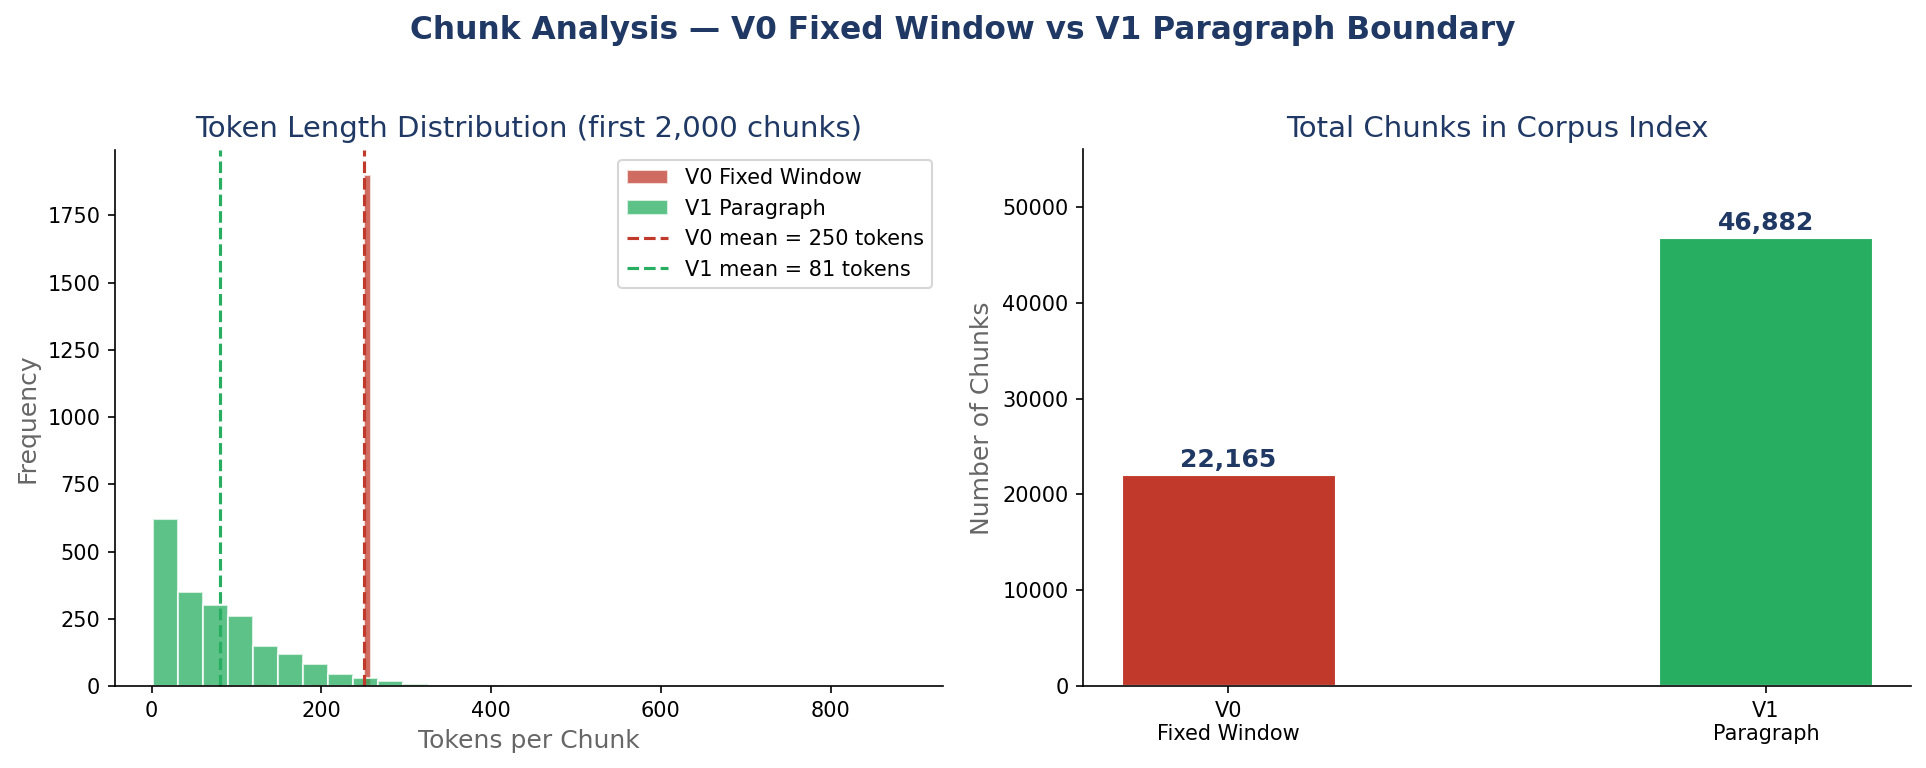

Saved → figures/fig2_chunk_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chunk Analysis — V0 Fixed Window vs V1 Paragraph Boundary',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# Token length histograms
axes[0].hist(v0_lengths, bins=30, color=RED, alpha=0.75, label='V0 Fixed Window', edgecolor='white')
axes[0].hist(v1_lengths, bins=30, color=GREEN, alpha=0.75, label='V1 Paragraph', edgecolor='white')
axes[0].axvline(sum(v0_lengths)/len(v0_lengths), color=RED, linestyle='--', linewidth=1.5,
                label=f'V0 mean = {sum(v0_lengths)/len(v0_lengths):.0f} tokens')
axes[0].axvline(sum(v1_lengths)/len(v1_lengths), color=GREEN, linestyle='--', linewidth=1.5,
                label=f'V1 mean = {sum(v1_lengths)/len(v1_lengths):.0f} tokens')
axes[0].set_title('Token Length Distribution (first 2,000 chunks)', color=NAVY)
axes[0].set_xlabel('Tokens per Chunk', color=GREY)
axes[0].set_ylabel('Frequency', color=GREY)
axes[0].legend()

# Corpus size comparison
variants   = ['V0\nFixed Window', 'V1\nParagraph']
chunk_counts = [len(v0_chunks), len(v1_chunks)]
colours_bar = [RED, GREEN]
bars = axes[1].bar(variants, chunk_counts, color=colours_bar, width=0.4,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, chunk_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom',
                 fontsize=12, color=NAVY, fontweight='bold')
axes[1].set_title('Total Chunks in Corpus Index', color=NAVY)
axes[1].set_ylabel('Number of Chunks', color=GREY)
axes[1].set_ylim(0, 56000)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig2_chunk_analysis.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Section 5 — Results Comparison: V0 vs V1 vs V2

In [13]:
# Extract mean scores
def mean_score(results, key):
    vals = [r[key] for r in results if key in r]
    return round(sum(vals)/len(vals), 4) if vals else 0.0

summary = {
    'V0': {
        'Context Recall':    mean_score(v0_results, 'context_recall'),
        'Context Precision': mean_score(v0_results, 'context_precision'),
        'Faithfulness':      mean_score(v0_results, 'faithfulness'),
        'Prov Coverage':     0.0,  # not applicable
    },
    'V1': {
        'Context Recall':    mean_score(v1_results, 'context_recall'),
        'Context Precision': mean_score(v1_results, 'context_precision'),
        'Faithfulness':      mean_score(v1_results, 'faithfulness'),
        'Prov Coverage':     0.0,
    },
    'V2': {
        'Context Recall':    mean_score(v2_results, 'context_recall'),
        'Context Precision': mean_score(v2_results, 'context_precision'),
        'Faithfulness':      mean_score(v2_results, 'faithfulness'),
        'Prov Coverage':     mean_score(v2_results, 'provenance_coverage'),
    },
}

print('Mean scores across pilot queries:')
print(f'{"Metric":<22} {"V0":>8} {"V1":>8} {"V2":>8}')
print('-' * 50)
for metric in ['Context Recall', 'Context Precision', 'Faithfulness', 'Prov Coverage']:
    v0s = summary['V0'][metric]
    v1s = summary['V1'][metric]
    v2s = summary['V2'][metric]
    print(f'{metric:<22} {v0s:>8.3f} {v1s:>8.3f} {v2s:>8.3f}')

Mean scores across pilot queries:
Metric                       V0       V1       V2
--------------------------------------------------
Context Recall            0.475    0.436    0.498
Context Precision         0.270    0.000    0.000
Faithfulness              0.083    0.000    0.200
Prov Coverage             0.000    0.000    0.480


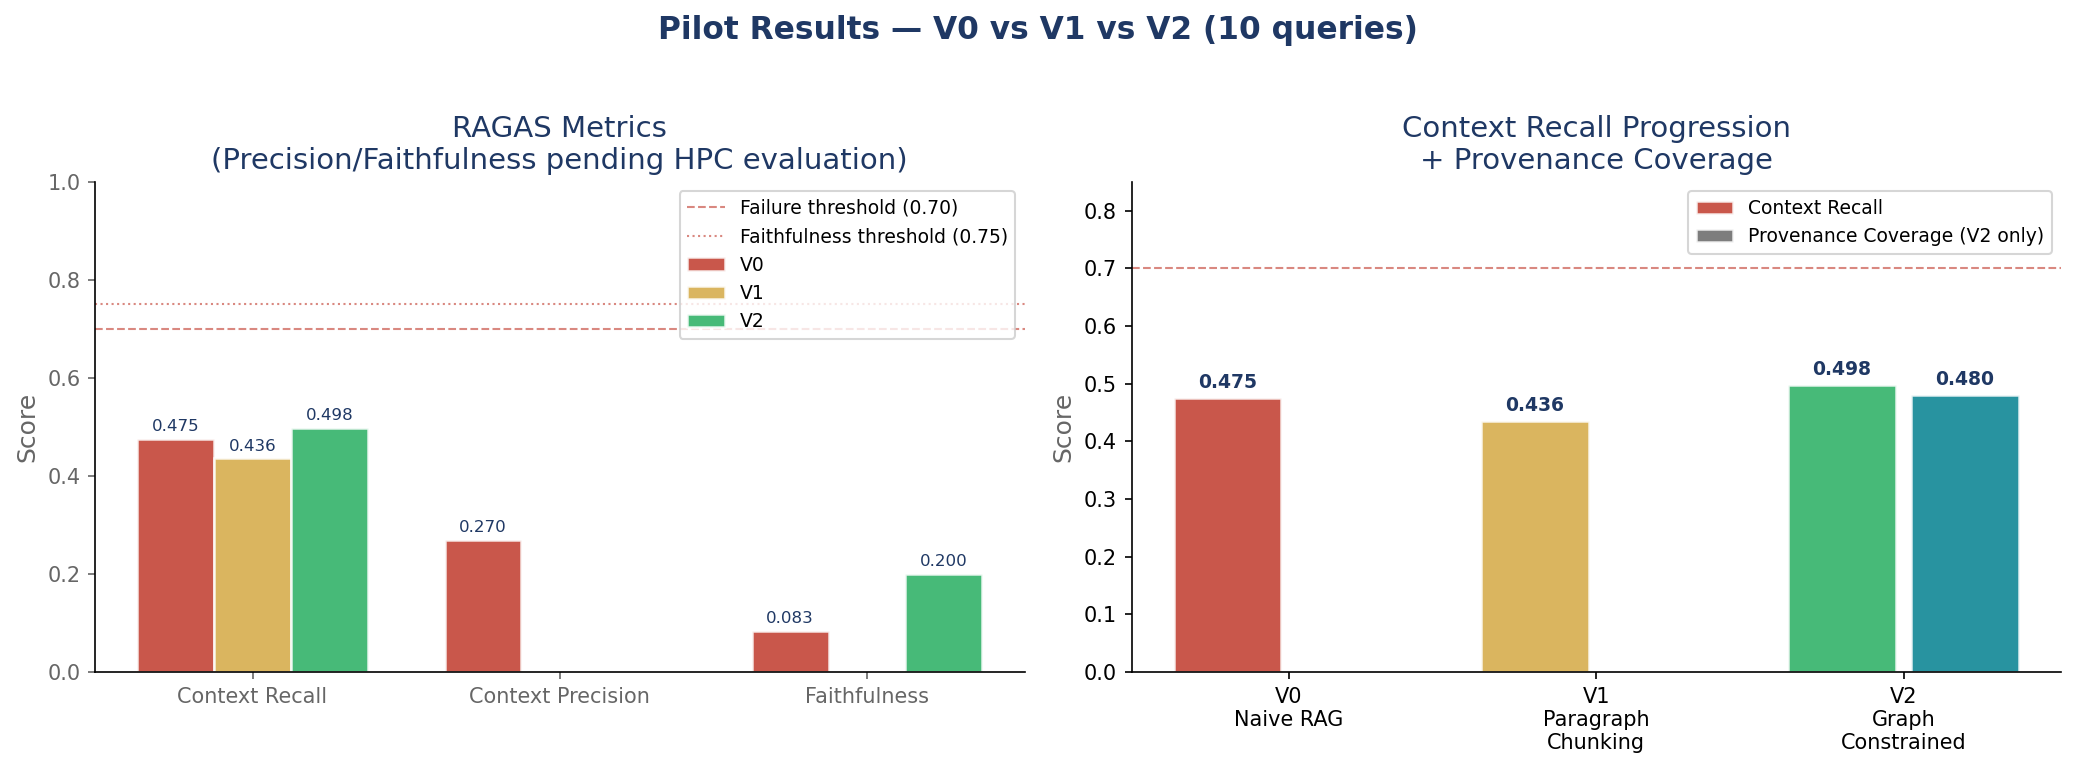

Saved → figures/fig3_results_comparison.png


In [14]:
# ── Figure 3: Results Comparison Bar Chart
metrics = ['Context Recall', 'Context Precision', 'Faithfulness']
x       = np.arange(len(metrics))
width   = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pilot Results — V0 vs V1 vs V2 (10 queries)',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# RAGAS metrics
for i, (variant, colour) in enumerate(VARIANT_COLOURS.items()):
    vals = [summary[variant][m] for m in metrics]
    bars = axes[0].bar(x + i*width, vals, width, label=variant,
                       color=colour, alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        if val > 0.01:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                         f'{val:.3f}', ha='center', va='bottom', fontsize=8, color=NAVY)

# Failure thresholds
axes[0].axhline(0.70, color=RED, linestyle='--', linewidth=1, alpha=0.6, label='Failure threshold (0.70)')
axes[0].axhline(0.75, color=RED, linestyle=':', linewidth=1, alpha=0.6, label='Faithfulness threshold (0.75)')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score', color=GREY)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('RAGAS Metrics\n(Precision/Faithfulness pending HPC evaluation)', color=NAVY)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].tick_params(colors=GREY)

# Context Recall focused + Provenance Coverage
recall_vals = [summary[v]['Context Recall'] for v in ['V0', 'V1', 'V2']]
prov_vals   = [summary[v]['Prov Coverage']  for v in ['V0', 'V1', 'V2']]
x2          = np.arange(3)

bars1 = axes[1].bar(x2 - 0.2, recall_vals, 0.35, label='Context Recall',
                    color=[RED, GOLD, GREEN], alpha=0.85, edgecolor='white', linewidth=1.2)
bars2 = axes[1].bar(x2 + 0.2, prov_vals, 0.35, label='Provenance Coverage (V2 only)',
                    color=[GREY, GREY, TEAL], alpha=0.85, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars1, recall_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, color=NAVY, fontweight='bold')
for bar, val in zip(bars2, prov_vals):
    if val > 0.01:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, color=NAVY, fontweight='bold')

axes[1].axhline(0.70, color=RED, linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['V0\nNaive RAG', 'V1\nParagraph\nChunking', 'V2\nGraph\nConstrained'])
axes[1].set_ylabel('Score', color=GREY)
axes[1].set_ylim(0, 0.85)
axes[1].set_title('Context Recall Progression\n+ Provenance Coverage', color=NAVY)
axes[1].legend(fontsize=9)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig3_results_comparison.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Section 6 — Per-Query Breakdown Heatmap

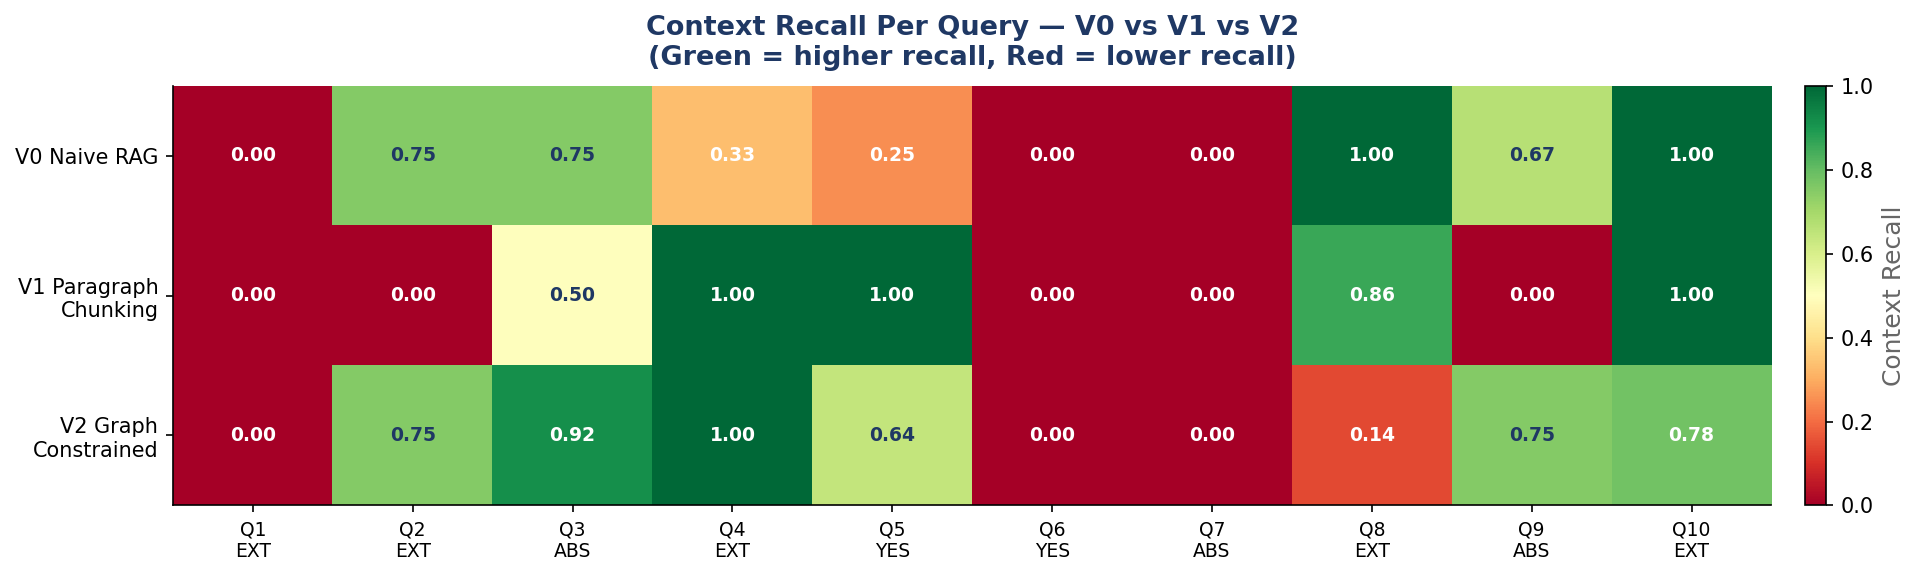

Saved → figures/fig4_per_query_heatmap.png


In [16]:
# ── Figure 4: Per-query recall heatmap across all three variants
import matplotlib.colors as mcolors

n_queries = len(v0_results)
recall_matrix = np.array([
    [r['context_recall'] for r in v0_results],
    [r['context_recall'] for r in v1_results],
    [r['context_recall'] for r in v2_results],
])

query_labels = [f"Q{i+1}\n{r['answer_type'][:3].upper()}" for i, r in enumerate(v0_results)]
variant_labels = ['V0 Naive RAG', 'V1 Paragraph\nChunking', 'V2 Graph\nConstrained']

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Annotate cells
for i in range(3):
    for j in range(n_queries):
        val = recall_matrix[i, j]
        colour = 'white' if val < 0.4 or val > 0.75 else NAVY
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=colour)

ax.set_xticks(range(n_queries))
ax.set_xticklabels(query_labels, fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels(variant_labels, fontsize=10)
ax.set_title('Context Recall Per Query — V0 vs V1 vs V2\n(Green = higher recall, Red = lower recall)',
             color=NAVY, fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Context Recall', color=GREY)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig4_per_query_heatmap.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Section 7 — Provenance Coverage (V2 Only)

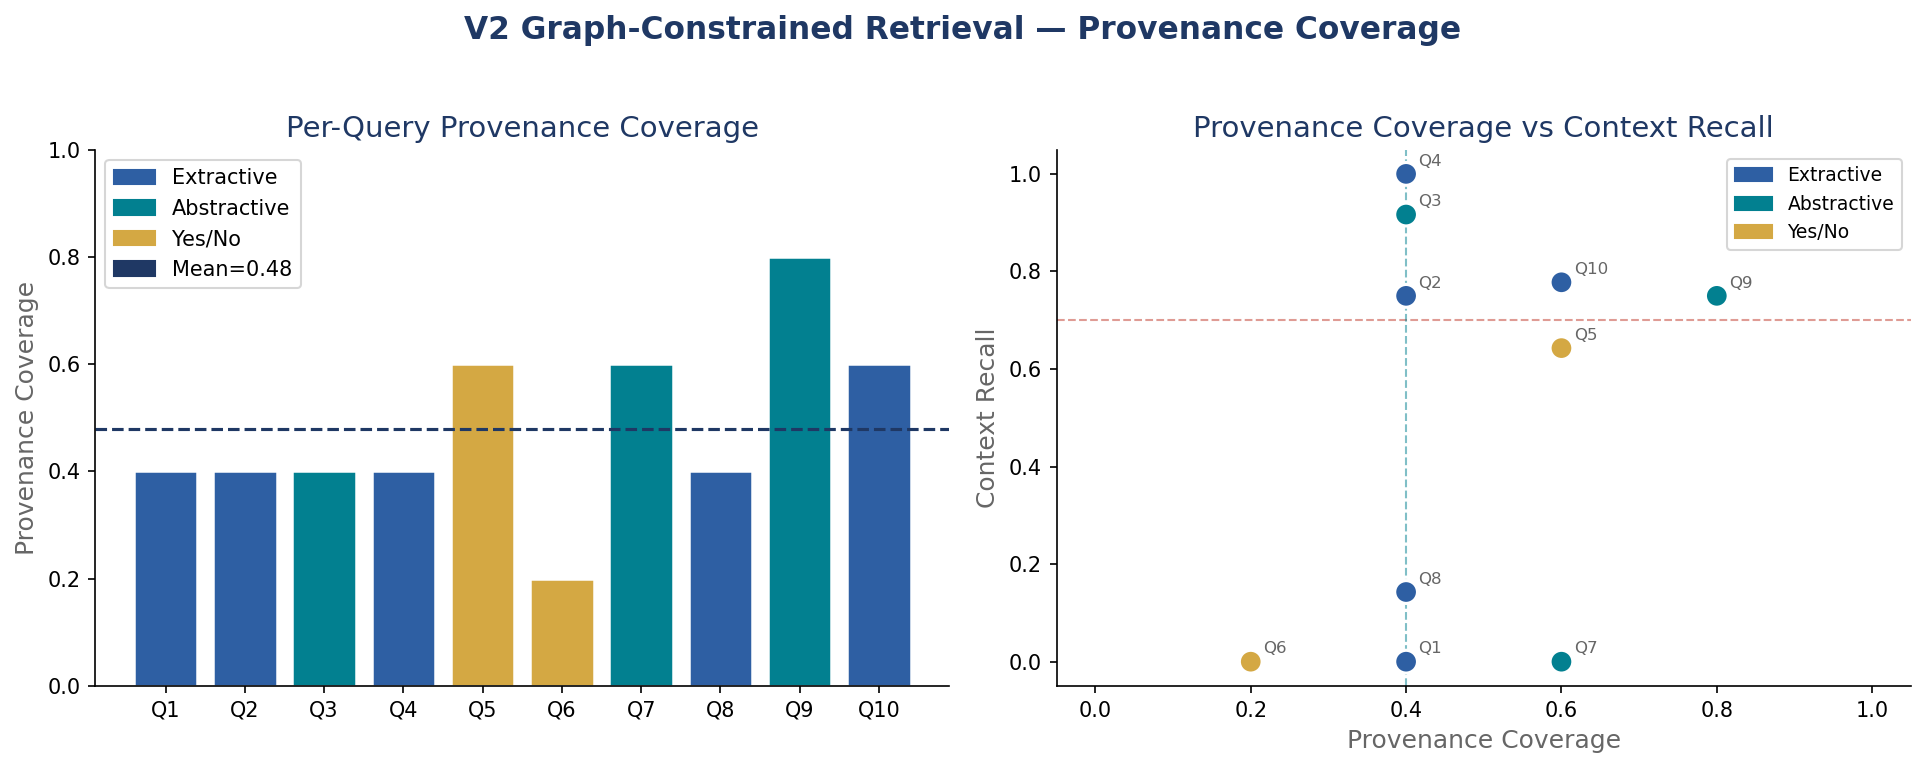

Saved → figures/fig5_provenance_coverage.png


In [18]:
# ── Figure 5: Provenance Coverage per query
prov_scores   = [r['provenance_coverage'] for r in v2_results]
recall_scores = [r['context_recall']      for r in v2_results]
answer_types  = [r['answer_type']         for r in v2_results]

type_colours = {'extractive': BLUE, 'abstractive': TEAL, 'yes_no': GOLD}
colours_list = [type_colours.get(t, GREY) for t in answer_types]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('V2 Graph-Constrained Retrieval — Provenance Coverage',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# Provenance per query bar chart
x = np.arange(len(prov_scores))
bars = axes[0].bar(x, prov_scores, color=colours_list, edgecolor='white', linewidth=1.2)
axes[0].axhline(np.mean(prov_scores), color=NAVY, linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(prov_scores):.2f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Q{i+1}' for i in range(len(prov_scores))])
axes[0].set_ylabel('Provenance Coverage', color=GREY)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Per-Query Provenance Coverage', color=NAVY)
axes[0].legend()
legend_patches = [mpatches.Patch(color=c, label=t.replace('_', '/').title())
                  for t, c in type_colours.items()]
axes[0].legend(handles=legend_patches + [mpatches.Patch(color=NAVY, label=f'Mean={np.mean(prov_scores):.2f}')])

# Provenance vs Recall scatter
axes[1].scatter(prov_scores, recall_scores, c=colours_list, s=120,
                edgecolors='white', linewidths=1.5, zorder=3)
for i, (px, py) in enumerate(zip(prov_scores, recall_scores)):
    axes[1].annotate(f'Q{i+1}', (px, py), textcoords='offset points',
                     xytext=(6, 4), fontsize=8, color=GREY)
axes[1].set_xlabel('Provenance Coverage', color=GREY)
axes[1].set_ylabel('Context Recall', color=GREY)
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title('Provenance Coverage vs Context Recall', color=NAVY)
axes[1].axhline(0.70, color=RED, linestyle='--', alpha=0.5, linewidth=1)
axes[1].axvline(0.40, color=TEAL, linestyle='--', alpha=0.5, linewidth=1)
axes[1].legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig5_provenance_coverage.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Section 8 — Graph Statistics

Graph Statistics:
  Total nodes:      59,300
  Real paragraph nodes: 46,882
  Virtual section nodes: 12,418
  Total edges:      81,346
  Sequential edges: 34,464
  Section edges:    46,882


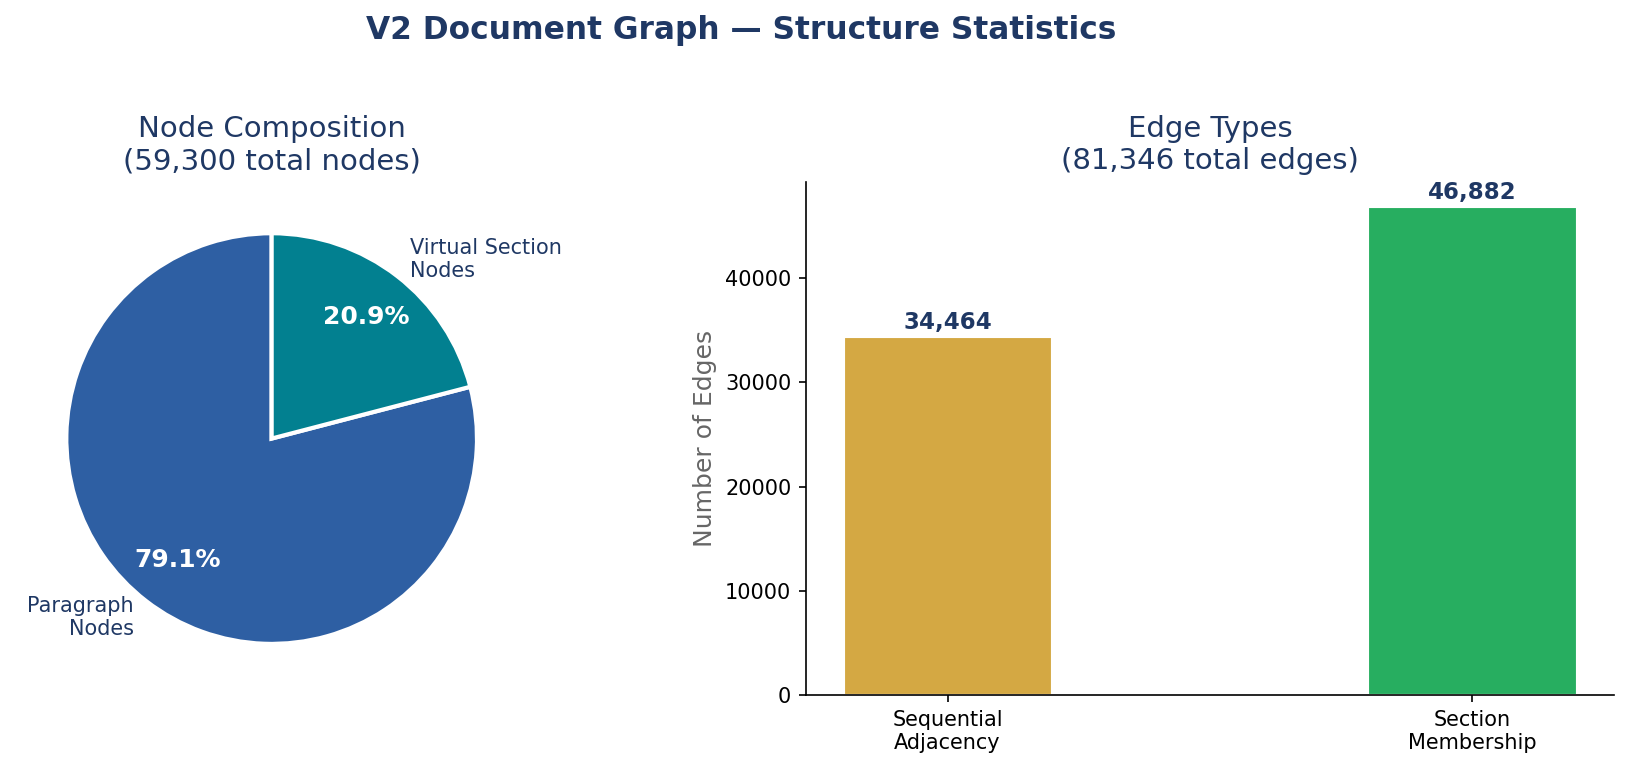

Saved → figures/fig6_graph_statistics.png


In [20]:
# ── Figure 6: Graph structure statistics
import pickle
import networkx as nx

with open(os.path.join(DATA_DIR, 'v2_graph.pkl'), 'rb') as f:
    G = pickle.load(f)

real_nodes    = len(v1_chunks)
virtual_nodes = G.number_of_nodes() - real_nodes
total_edges   = G.number_of_edges()

# Count edge types
seq_edges  = sum(1 for _, _, d in G.edges(data=True) if d.get('type') == 'sequential')
sec_edges  = sum(1 for _, _, d in G.edges(data=True) if d.get('type') == 'section')

print(f'Graph Statistics:')
print(f'  Total nodes:      {G.number_of_nodes():,}')
print(f'  Real paragraph nodes: {real_nodes:,}')
print(f'  Virtual section nodes: {virtual_nodes:,}')
print(f'  Total edges:      {total_edges:,}')
print(f'  Sequential edges: {seq_edges:,}')
print(f'  Section edges:    {sec_edges:,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('V2 Document Graph — Structure Statistics',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

# Node composition
node_labels  = ['Paragraph\nNodes', 'Virtual Section\nNodes']
node_values  = [real_nodes, virtual_nodes]
node_colours = [BLUE, TEAL]
wedges, texts, autotexts = axes[0].pie(
    node_values, labels=node_labels, colors=node_colours,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75,
)
for text in texts:
    text.set_color(NAVY)
for autotext in autotexts:
    autotext.set_color(WHITE)
    autotext.set_fontweight('bold')
axes[0].set_title(f'Node Composition\n({G.number_of_nodes():,} total nodes)', color=NAVY)

# Edge composition
edge_labels  = ['Sequential\nAdjacency', 'Section\nMembership']
edge_values  = [seq_edges, sec_edges]
edge_colours = [GOLD, GREEN]
bars = axes[1].bar(edge_labels, edge_values, color=edge_colours,
                   width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, edge_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom',
                 fontsize=11, color=NAVY, fontweight='bold')
axes[1].set_title(f'Edge Types\n({total_edges:,} total edges)', color=NAVY)
axes[1].set_ylabel('Number of Edges', color=GREY)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig6_graph_statistics.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Section 9 — Failure Mode Analysis

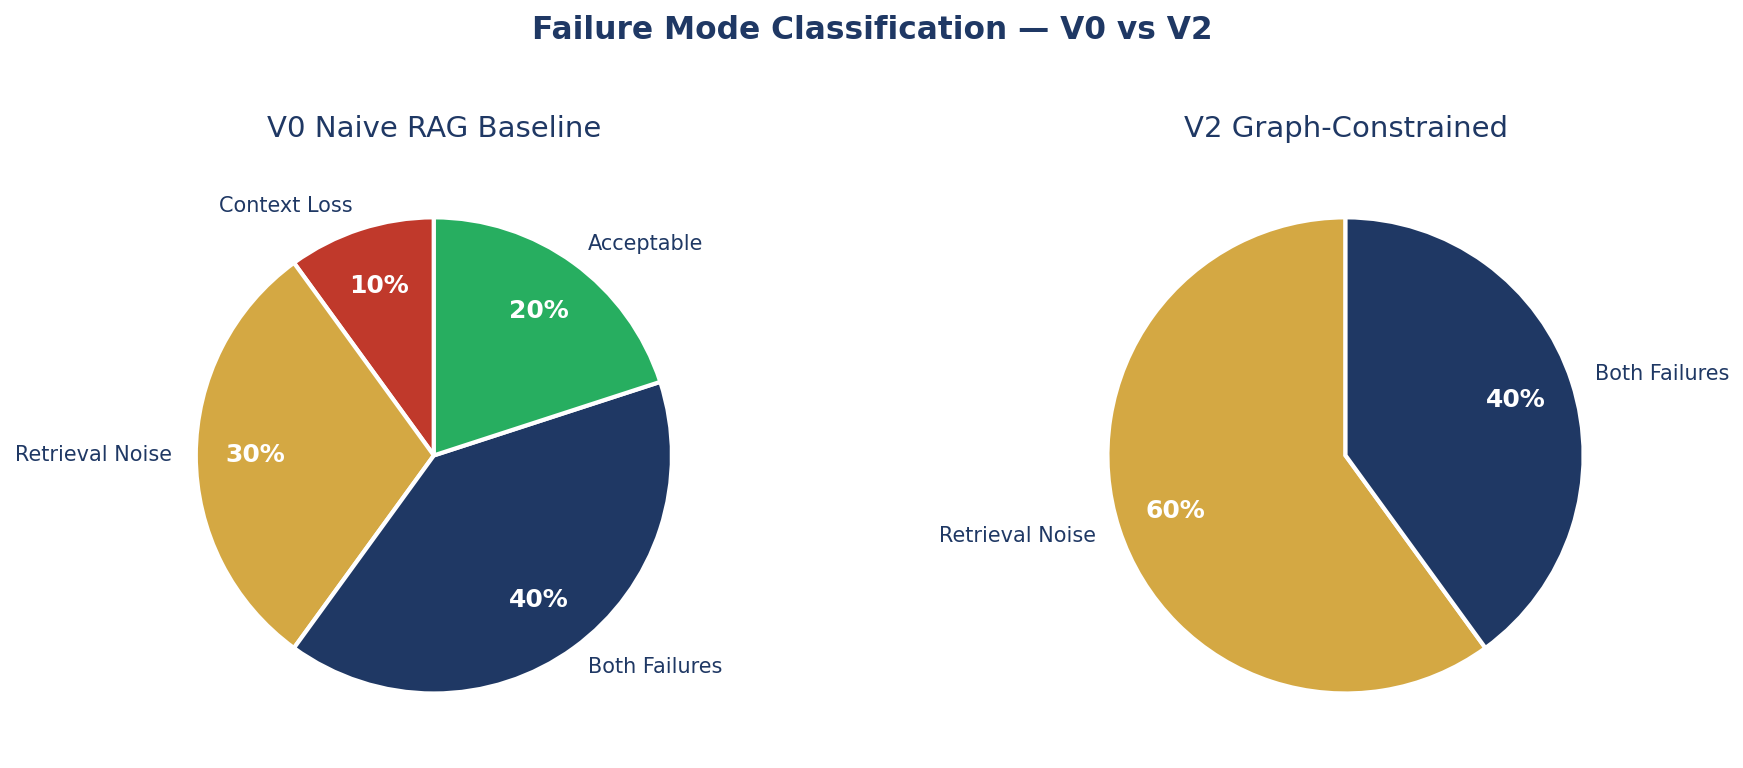

Saved → figures/fig7_failure_mode_analysis.png


In [22]:
# ── Figure 7: Failure mode classification per query
# Classify each V0 query into failure mode
def classify_failure(r):
    recall    = r.get('context_recall', 0)
    precision = r.get('context_precision', 0)
    if recall < 0.5 and precision < 0.3:
        return 'Both Failures'
    elif recall < 0.5:
        return 'Context Loss'
    elif precision < 0.3:
        return 'Retrieval Noise'
    else:
        return 'Acceptable'

v0_failures = [classify_failure(r) for r in v0_results]
v2_failures = [classify_failure(r) for r in v2_results]

failure_types  = ['Context Loss', 'Retrieval Noise', 'Both Failures', 'Acceptable']
failure_colours = [RED, GOLD, NAVY, GREEN]

v0_counts = [v0_failures.count(f) for f in failure_types]
v2_counts = [v2_failures.count(f) for f in failure_types]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Failure Mode Classification — V0 vs V2',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

for ax, counts, title in zip(axes, [v0_counts, v2_counts],
                              ['V0 Naive RAG Baseline', 'V2 Graph-Constrained']):
    non_zero = [(f, c, col) for f, c, col in zip(failure_types, counts, failure_colours) if c > 0]
    if non_zero:
        labels, vals, cols = zip(*non_zero)
        wedges, texts, autotexts = ax.pie(
            vals, labels=labels, colors=cols,
            autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            pctdistance=0.75,
        )
        for text in texts:
            text.set_color(NAVY)
            text.set_fontsize(10)
        for autotext in autotexts:
            autotext.set_color(WHITE)
            autotext.set_fontweight('bold')
    ax.set_title(title, color=NAVY, pad=10)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, 'fig7_failure_mode_analysis.png')
plt.savefig(path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved → {path}')

## Summary — All Figures Generated

In [24]:
figures = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')])
print('All figures saved to figures/ directory:')
print()
for fig_file in figures:
    size_kb = os.path.getsize(os.path.join(FIGURES_DIR, fig_file)) / 1024
    print(f'  {fig_file:<45} {size_kb:.0f} KB')
print()
print('Use these figures in the presentation deck.')

All figures saved to figures/ directory:

  fig1_qasper_distribution.png                  98 KB
  fig2_chunk_analysis.png                       109 KB
  fig3_results_comparison.png                   121 KB
  fig4_per_query_heatmap.png                    75 KB
  fig5_provenance_coverage.png                  110 KB
  fig6_graph_statistics.png                     91 KB
  fig7_failure_mode_analysis.png                97 KB

Use these figures in the presentation deck.
